In [1]:
import json

documents = json.load(open("lufthansa_data.json", encoding="utf-8"))
print("Loaded:", len(documents), "docs\n")

# Inspect a few raw texts to see what cleaning they need
for d in documents[:5]:
    print(repr(d["text"]))   
    print("---")

Loaded: 200 docs

'Financial reports - Lufthansa Group Investor Relations. Financial reports 2024 Annual Report 2024 Documents Annual Report 2024 Online Annual Report 2024 Financial Statements 2024 Management Presentation on the Results Quarterly data 2023 & 2024 Consensus Q4 2024 ESEF documents Factsheet Sustainability 2024 Lufthansa Group CDP Response 2024 3rd Interim Report January-September 2024 Documents 3rd ...'
---
'Financial reports & publications - Lufthansa Group Investor Relations. The Lufthansa Group reports in detail about the sustainable commitment regarding its material topics in the non-financial declaration which is a part of the annual report with reference to the GRI standards. This also includes a statement regarding the applicability of the EU Taxonomy Regulation and is subject to an independent limited assurance engagement. Further reports on data and facts ...'
---
'Financial Data - Lufthansa Technik. Three-quarters of revenue now comes from business with custome

### Cleaning  
    whitespace normalization and dropping too-short/junk docs ( a doc with 5 characters is noise)
#### I deliberately avoided stopword removal, stemming, and lowercasing, because sentence-transformer embeddings are trained on natural language and rely on case, punctuation, and stopwords for meaning. Heavy cleaning helps BoW/TF-IDF, not embeddings.

In [2]:
import re

def clean_text(text):
    text = re.sub(r"\s+", " ", text)  
    text = re.sub(r"\.{2,}", ".", text)
    text = text.strip()               
    return text

In [3]:
cleaned_docs = []
for d in documents:
    t = clean_text(d["text"])
    if len(t) > 30:          
        d["text"] = t       
        cleaned_docs.append(d)

print("Before cleaning:", len(documents))
print("After cleaning: ", len(cleaned_docs))

Before cleaning: 200
After cleaning:  200


In [4]:
import chromadb
client = chromadb.PersistentClient(path="chroma_db")

In [5]:
ids       = [str(i) for i in range(len(cleaned_docs))]              # unique ID per doc
texts     = [d["text"] for d in cleaned_docs]                       # the text to embed
metadatas = [{"source": d["source"], "url": d["url"]} for d in cleaned_docs]  # evidence

In [6]:
collection = client.get_or_create_collection("lufthansa")

collection.add(
    documents=texts,
    metadatas=metadatas,
    ids=ids,
)

print("Stored:", collection.count(), "documents")

Stored: 200 documents


In [7]:
results = collection.query(
    query_texts=["What are the biggest risks for Lufthansa?"],
    n_results=3
)

for doc, meta in zip(results["documents"][0], results["metadatas"][0]):
    print(f"[{meta['source']}] {doc[:150]}")
    print(f"    {meta['url']}\n")

[news] Deutsche Lufthansa : Lufthansa CEO sees. | MarketScreener. Lufthansa expects the level of business travel in the medium term to be around 90% or more 
    https://www.marketscreener.com/quote/stock/LUFTHANSA-436827/news/Deutsche-Lufthansa-Lufthansa-CEO-sees-business-travel-recovering-faster-than-thought-36769814/

[news] Current information | Lufthansa. Get the latest flight information including updates on routes, cancellations due to weather conditions or strikes, re
    https://www.lufthansa.com/us/en/prepare-for-your-trip/current-travel-information

[company] Downloads - report.lufthansagroup.com. Overall statement by the Executive Board on the expected development of the Lufthansa Group Disclosures in acco
    https://report.lufthansagroup.com/2024/annual-report/en/downloads/



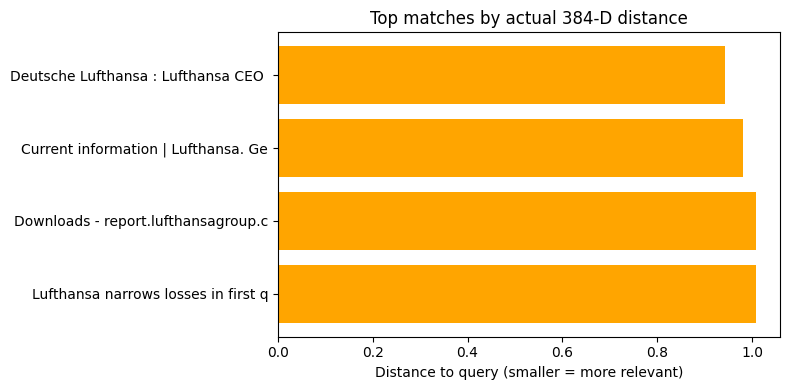

In [8]:
import matplotlib.pyplot as plt

results = collection.query(query_texts=["What are the biggest risks for Lufthansa?"], n_results=5)   # distances returned by default
docs  = [d[:35] for d in results["documents"][0]]
dists = results["distances"][0]

plt.figure(figsize=(8, 4))
plt.barh(docs, dists, color="orange")
plt.xlabel("Distance to query (smaller = more relevant)")
plt.title("Top matches by actual 384-D distance")
plt.gca().invert_yaxis()      # best match on top
plt.tight_layout(); plt.show()


d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


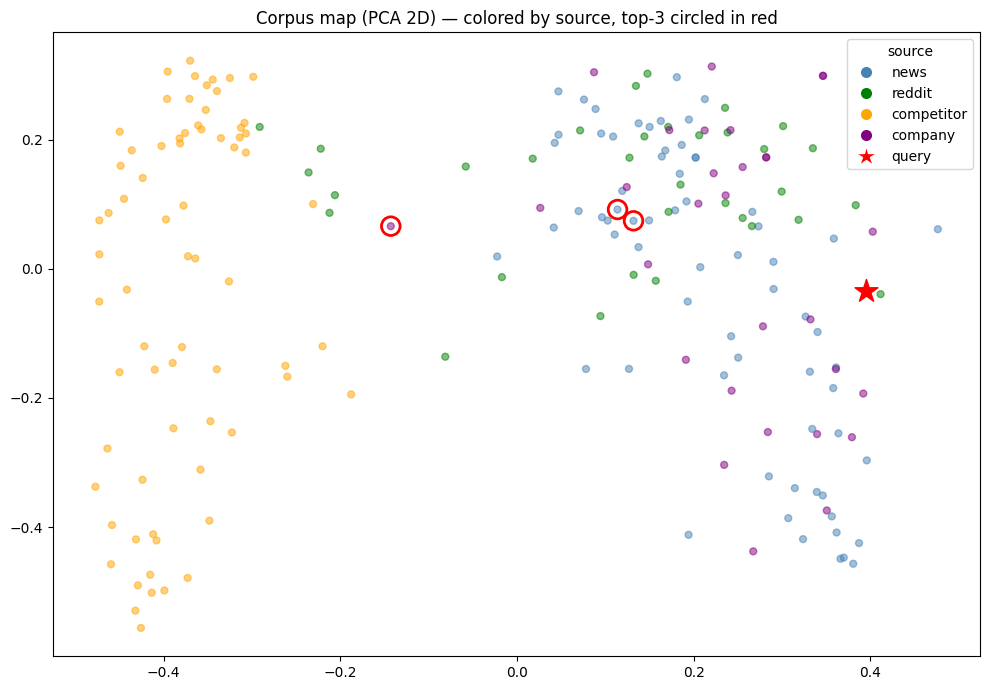

In [9]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

query = "What are the biggest risks for Lufthansa?"

# 1. embed docs + query
model   = SentenceTransformer("all-MiniLM-L6-v2")
doc_emb = model.encode(texts)
q_emb   = model.encode([query])

# 2. squash 384 -> 2
coords = PCA(n_components=2).fit_transform(np.vstack([doc_emb, q_emb]))
doc_xy, q_xy = coords[:-1], coords[-1]

# 3. get the real top-3 from Chroma (ids = positions)
results = collection.query(query_texts=[query], n_results=3)
top_idx = [int(i) for i in results["ids"][0]]

# 4. color each doc by its source (aligned with texts via cleaned_docs)
cmap = {"news": "steelblue", "reddit": "green", "competitor": "orange", "company": "purple"}
pt_colors = [cmap[d["source"]] for d in cleaned_docs]

# 5. plot
plt.figure(figsize=(10, 7))
plt.scatter(doc_xy[:, 0], doc_xy[:, 1], c=pt_colors, s=25, alpha=0.5)                 # all docs
plt.scatter(doc_xy[top_idx, 0], doc_xy[top_idx, 1], s=180, facecolor="none",          # circle top-3
            edgecolor="red", linewidth=2, zorder=5)
plt.scatter(q_xy[0], q_xy[1], c="red", s=300, marker="*", zorder=6)                   # query

# custom legend (sources + query)
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=s)
           for s, c in cmap.items()]
handles.append(Line2D([0], [0], marker="*", color="w", markerfacecolor="red", markersize=16, label="query"))
plt.legend(handles=handles, title="source")
plt.title("Corpus map (PCA 2D) — colored by source, top-3 circled in red")
plt.tight_layout(); plt.show()

In [10]:
%pip install rank_bm25

Note: you may need to restart the kernel to use updated packages.


In [11]:
from rank_bm25 import BM25Okapi

# tokenize each document (lowercase + split into words) — BM25 works on word lists
tokenized_corpus = [doc.lower().split() for doc in texts]

bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index built over", len(tokenized_corpus), "docs")

BM25 index built over 200 docs


In [12]:
query = "Lufthansa A350 fleet order"

bm25_scores = bm25.get_scores(query.lower().split())

print(type(bm25_scores))
print(len(bm25_scores))
print(bm25_scores[:10])     # first 10 scores

<class 'numpy.ndarray'>
200
[1.41012994 1.26775489 1.6732022  1.48337407 1.54932757 1.52425044
 1.52425044 1.68819975 1.1016202  1.784152  ]


In [14]:
doc_emb = model.encode(texts)      # 200 docs → 200 x 384, takes a few seconds

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

q_emb = model.encode([query])                       # embed the query → 1 x 384
dense_scores = cosine_similarity(q_emb, doc_emb)[0] # compare query to all docs

print(type(dense_scores))
print(len(dense_scores))
print(dense_scores[:10])

<class 'numpy.ndarray'>
200
[0.38271427 0.37968674 0.31586063 0.4027638  0.3925298  0.40450695
 0.42611647 0.39428216 0.45673132 0.31842333]


```python
bm25_scores[:5]   -> [1.41, 1.27, 1.67, 1.48, 1.55]   <- keyword, scale ~0 to 2
dense_scores[:5]  -> [0.38, 0.38, 0.32, 0.40, 0.39]   <- meaning, scale ~0 to 0.5
```

If we just added them, BM25's bigger numbers (1.4) would dominate the dense ones (0.4) — keyword would win unfairly. So first we put both on the same 0–1 scale.

In [16]:
import numpy as np

def normalize(x):
    x = np.array(x)
    return (x - x.min()) / (x.max() - x.min())

bm25_norm  = normalize(bm25_scores)
dense_norm = normalize(dense_scores)

print("bm25_norm  range:", bm25_norm.min(), "to", bm25_norm.max())
print("dense_norm range:", dense_norm.min(), "to", dense_norm.max())
print(bm25_norm[:5])
print(dense_norm[:5])

bm25_norm  range: 0.0 to 1.0
dense_norm range: 0.0 to 1.0
[0.09359553 0.08414557 0.1110566  0.09845701 0.10283459]
[0.41392797 0.41006154 0.32854968 0.4395331  0.4264633 ]


In [17]:
alpha = 0.5
combined = alpha * dense_norm + (1 - alpha) * bm25_norm

print(combined[:5])

[0.25376175 0.24710355 0.21980314 0.26899506 0.26464895]


```python
alpha = 0.5  →  50% semantic, 50% keyword   (equal trust)
alpha = 0.6  →  60% semantic, 40% keyword   (lean semantic)
alpha = 0.4  →  40% semantic, 60% keyword   (lean keyword)
```

# RANKING

In [ ]:
k = 5
top_idx = np.argsort(combined)[::-1][:k]

print(f"Top {k} HYBRID results:\n")
for rank, i in enumerate(top_idx, 1):
    print(f"#{rank}  score={combined[i]:.3f}  [{cleaned_docs[i]['source']}]")
    print(f"     {texts[i][:120]}")
    print()

Top 5 HYBRID results:

#1  score=1.000  [news]
     Lufthansa Fleet of A350 (On order) | Airfleets aviation. Fleet Lufthansa Graph Lufthansa Full fleet in PDF format Photos

#2  score=0.680  [news]
     Fleet - Lufthansa Group Investor Relations. Fleet orders. At year-end 2025, there were 219 aircraft on the Lufthansa Gro

#3  score=0.626  [news]
     Lufthansa Group orders A350-900s and. - Live From A Lounge. This week, Lufthansa Group placed a further order for 20 A35

#4  score=0.528  [news]
     Lufthansa fleet - Wikiwand. Additionally, Lufthansa currently has orders placed for further new Airbus A320neo, A350, an

#5  score=0.526  [news]
     Lufthansa - Wikipedia. In March 2019, Lufthansa ordered 20 Boeing 787-9 and an additional 20 Airbus A350-900 for its own



In [19]:
# Pure SEMANTIC ranking (dense only, no BM25)
sem_idx = np.argsort(dense_scores)[::-1][:5]

print("=== PURE SEMANTIC (meaning only) ===\n")
for rank, i in enumerate(sem_idx, 1):
    print(f"#{rank}  {texts[i][:90]}")

print("\n=== HYBRID (meaning + keyword) ===\n")
for rank, i in enumerate(top_idx, 1):
    print(f"#{rank}  {texts[i][:90]}")

=== PURE SEMANTIC (meaning only) ===

#1  Lufthansa Fleet of A350 (On order) | Airfleets aviation. Fleet Lufthansa Graph Lufthansa F
#2  Lufthansa Group orders A350-900s and. - Live From A Lounge. This week, Lufthansa Group pla
#3  Fleet - Lufthansa Group Investor Relations. Fleet orders. At year-end 2025, there were 219
#4  Lufthansa fleet - Wikiwand. Additionally, Lufthansa currently has orders placed for furthe
#5  Lufthansa - Wikipedia. In March 2019, Lufthansa ordered 20 Boeing 787-9 and an additional 

=== HYBRID (meaning + keyword) ===

#1  Lufthansa Fleet of A350 (On order) | Airfleets aviation. Fleet Lufthansa Graph Lufthansa F
#2  Fleet - Lufthansa Group Investor Relations. Fleet orders. At year-end 2025, there were 219
#3  Lufthansa Group orders A350-900s and. - Live From A Lounge. This week, Lufthansa Group pla
#4  Lufthansa fleet - Wikiwand. Additionally, Lufthansa currently has orders placed for furthe
#5  Lufthansa - Wikipedia. In March 2019, Lufthansa ordered 20 Boeing 

In [20]:
def hybrid_search(query, k=5, alpha=0.5):
    # Step 1 — keyword scores
    bm25_scores  = bm25.get_scores(query.lower().split())

    # Step 2 — semantic scores
    q_emb        = model.encode([query])
    dense_scores = cosine_similarity(q_emb, doc_emb)[0]

    # Step 3 — normalize both, then combine
    bm25_norm  = normalize(bm25_scores)
    dense_norm = normalize(dense_scores)
    combined   = alpha * dense_norm + (1 - alpha) * bm25_norm

    # Step 4 — rank and return top-k
    top_idx = np.argsort(combined)[::-1][:k]
    return [
        {"text": texts[i], "score": round(float(combined[i]), 3),
         "source": cleaned_docs[i]["source"], "url": cleaned_docs[i]["url"]}
        for i in top_idx
    ]

In [21]:
for r in hybrid_search("Lufthansa A350 fleet order"):
    print(r["score"], "|", r["source"], "|", r["text"][:80])

1.0 | news | Lufthansa Fleet of A350 (On order) | Airfleets aviation. Fleet Lufthansa Graph L
0.68 | news | Fleet - Lufthansa Group Investor Relations. Fleet orders. At year-end 2025, ther
0.626 | news | Lufthansa Group orders A350-900s and. - Live From A Lounge. This week, Lufthansa
0.528 | news | Lufthansa fleet - Wikiwand. Additionally, Lufthansa currently has orders placed 
0.526 | news | Lufthansa - Wikipedia. In March 2019, Lufthansa ordered 20 Boeing 787-9 and an a
